# 05 — FPL Squad Optimizer

Uses Integer Linear Programming (PuLP) to:
1. **Select the optimal 15-man squad** from all available players given a £100m budget
2. **Visualise the squad** on a football pitch (mplsoccer)
3. **Recommend transfers** given a current squad and available budget
4. **Sensitivity analysis** — how does predicted value change with budget?

The optimizer uses the XGBoost predicted points from notebook 04 as its objective.

**Output:** `src/models/optimize.py` — `FPLOptimizer` class used by the Dash app.

## 1. Imports and setup

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.models.predict import FPLPredictor
from src.models.optimize import FPLOptimizer

PROCESSED = Path('../data/processed')
RAW       = Path('../data/raw')
MODELS    = Path('../models')

print('Libraries loaded.')

Libraries loaded.


## 2. Load features and generate predictions

We use the XGBoost model trained in notebook 04 to generate predicted points
for the **latest available gameweek** — these feed directly into the optimizer.

In [2]:
# Load feature data
features = pd.read_parquet(PROCESSED / 'features.parquet')
print(f'Features: {features.shape}')
print(f'Rounds available: {sorted(features["round"].unique())}')

Features: (22414, 37)
Rounds available: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [3]:
# Use the most recent gameweek as our 'current' snapshot
latest_gw = features['round'].max()
latest_df = features[features['round'] == latest_gw].copy()
print(f'Using GW{latest_gw} — {len(latest_df)} players with data')

# Load trained predictor
predictor = FPLPredictor(models_dir=MODELS)
predictor.load()

# Generate predictions
latest_df['predicted_pts'] = predictor.predict(latest_df)
print(f'Predictions generated. Range: {latest_df["predicted_pts"].min():.2f} — {latest_df["predicted_pts"].max():.2f}')
print(f'Mean predicted pts: {latest_df["predicted_pts"].mean():.2f}')

Using GW30 — 659 players with data
Predictions generated. Range: -0.27 — 10.93
Mean predicted pts: 1.17


In [4]:
# Build the player pool DataFrame the optimizer expects
# Columns needed: player_id, web_name, position, team, now_cost, predicted_pts

# Load FPL player info — only need web_name, status, team from here
fpl_players = pd.read_parquet(RAW / 'fpl_players.parquet')
POSITION_MAP = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}
fpl_players['position'] = fpl_players['element_type'].map(POSITION_MAP)
fpl_meta = fpl_players[['id', 'web_name', 'position', 'team', 'status']].rename(columns={'id': 'player_id'})

# Use latest_df for predicted_pts AND now_cost (stored as 'value' in features, already in £m)
# The feature engineer computes value = now_cost / 10 from raw API integers
player_pool = latest_df[['player_id', 'value', 'predicted_pts']].copy()
player_pool.rename(columns={'value': 'now_cost'}, inplace=True)

# Merge with metadata
players_df = player_pool.merge(fpl_meta, on='player_id', how='left')

# Sanity check — print price range
print(f'now_cost range: £{players_df["now_cost"].min():.1f}m — £{players_df["now_cost"].max():.1f}m')
print(f'Total players in feature snapshot: {len(players_df)}')

# Only include available players
players_available = players_df[fpl_meta.set_index('player_id').reindex(players_df['player_id'])['status'].values == 'a'].copy()
# Fallback: if status join missed players, just use all
if len(players_available) < 100:
    players_available = players_df.copy()
    print('Warning: status filter removed too many players — using full pool')

print(f'Available players: {len(players_available)}')
players_available.sort_values('predicted_pts', ascending=False).head(10)

now_cost range: £3.7m — £14.0m
Total players in feature snapshot: 659
Available players: 407


,player_id,now_cost,predicted_pts,web_name,position,team,status
355,449,10.1,10.927084,B.Fernandes,MID,14,a
414,508,4.7,10.703463,N.Williams,DEF,16,a
391,485,7.2,7.776890,Gordon,MID,15,a
411,505,5.1,7.730746,Milenković,DEF,16,a
263,329,6.0,7.231172,Wilson,MID,10,a
70,101,4.8,7.185807,Kelleher,GKP,5,a
421,515,7.3,6.849277,Gibbs-White,MID,16,a
412,506,5.2,6.151562,Murillo,DEF,16,a
408,502,4.6,5.961627,Sels,GKP,16,a
147,178,6.1,5.861396,Welbeck,FWD,6,a


## 3. Select optimal squad

The ILP optimizer picks the best 15 players (2 GKP, 5 DEF, 5 MID, 3 FWD)
within a £100m budget, with max 3 players per club. Captain is chosen automatically
as the player with the highest predicted points.

In [5]:
optimizer = FPLOptimizer(budget=100.0)
result    = optimizer.select_squad(players_available, budget=100.0)

print(f'Status:           {result["status"]}')
print(f'Total cost:       £{result["total_cost"]}m')
print(f'Captain:          {result["captain"]}')
print(f'Vice-captain:     {result["vice_captain"]}')
print(f'Predicted total:  {result["predicted_total"]} pts')

Status:           Optimal
Total cost:       £86.5m
Captain:          B.Fernandes
Vice-captain:     N.Williams
Predicted total:  111.56999969482422 pts


In [6]:
squad_df = result['squad']
print('=== Optimal Squad ===')
for pos in ['GKP', 'DEF', 'MID', 'FWD']:
    pos_players = squad_df[squad_df['position'] == pos]
    print(f'\n{pos}:')
    for _, row in pos_players.iterrows():
        cap_marker = ' ©' if row.get('is_captain') else ''
        print(f'  {row["web_name"]:<20} £{row["now_cost"]:.1f}m  {row["predicted_pts"]:.2f} pts{cap_marker}')

=== Optimal Squad ===

GKP:
  Kelleher             £4.8m  7.19 pts
  Martinez             £5.1m  4.80 pts

DEF:
  N.Williams           £4.7m  10.70 pts
  Milenković           £5.1m  7.73 pts
  Collins              £4.9m  5.64 pts
  Konsa                £4.4m  4.97 pts
  Bijol                £3.9m  4.71 pts

MID:
  B.Fernandes          £10.1m  10.93 pts ©
  Gordon               £7.2m  7.78 pts
  Wilson               £6.0m  7.23 pts
  Gibbs-White          £7.3m  6.85 pts
  King                 £4.4m  4.97 pts

FWD:
  Welbeck              £6.1m  5.86 pts
  Flemming             £5.3m  5.86 pts
  Thiago               £7.2m  5.42 pts


## 3b. Optimal starting XI

When playing without Bench Boost, only your 11 starters score points.
This runs a separate ILP with FPL formation rules:
- Exactly **1 GKP**
- **3–5 DEF**, **2–5 MID**, **1–3 FWD**
- Total = **11**

In [ ]:
xi_result = optimizer.select_starting_xi(players_available, budget=100.0)

print(f'Status:           {xi_result["status"]}')
print(f'Formation:        {xi_result["formation"]}')
print(f'Total cost:       £{xi_result["total_cost"]:.1f}m')
print(f'Captain:          {xi_result["captain"]}')
print(f'Vice-captain:     {xi_result["vice_captain"]}')
print(f'Predicted total:  {xi_result["predicted_total"]} pts')

print('\n=== Optimal Starting XI ===')
xi_df = xi_result['xi']
for pos in ['GKP', 'DEF', 'MID', 'FWD']:
    pos_players = xi_df[xi_df['position'] == pos]
    if pos_players.empty:
        continue
    print(f'\n{pos}:')
    for _, row in pos_players.iterrows():
        cap_marker = ' ©' if row.get('is_captain') else ''
        print(f'  {row["web_name"]:<20} £{row["now_cost"]:.1f}m  {row["predicted_pts"]:.2f} pts{cap_marker}')

## 4. Visualise squad on a pitch

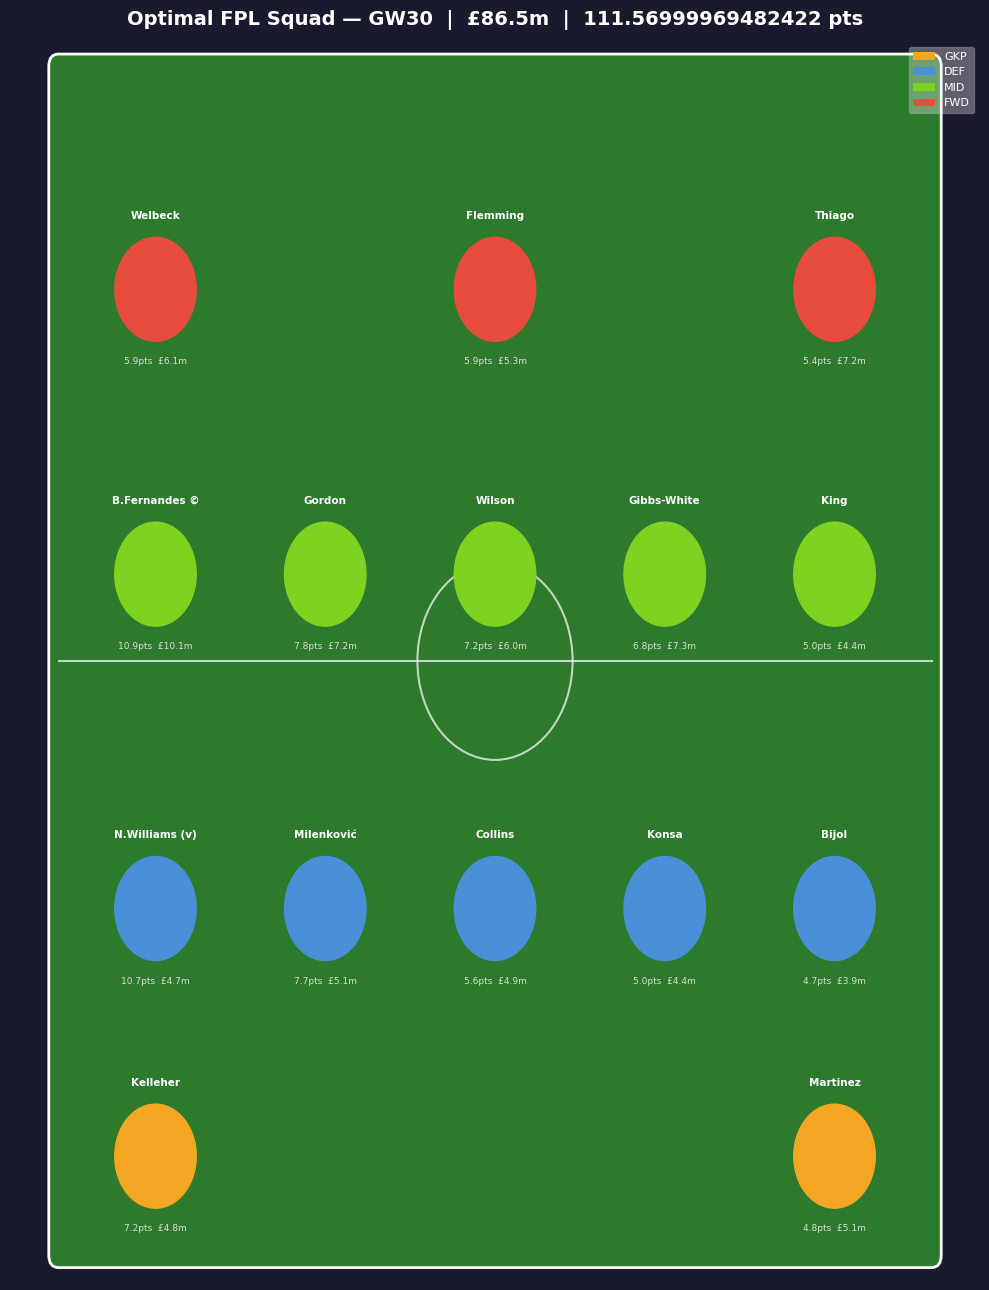

Saved to models/optimal_squad.png


In [7]:
def plot_squad_on_pitch(squad_df, captain_name, vice_name, title='Optimal FPL Squad'):
    """
    Draw a simple football pitch and place players by position.
    GKP at bottom, then DEF, MID, FWD rows.
    """
    fig, ax = plt.subplots(figsize=(10, 13))
    ax.set_facecolor('#2d7a2d')  # grass green
    fig.patch.set_facecolor('#1a1a2e')

    # Draw pitch lines
    pitch_rect = mpatches.FancyBboxPatch((0.05, 0.02), 0.90, 0.96,
                                          boxstyle='round,pad=0.01',
                                          linewidth=2, edgecolor='white',
                                          facecolor='#2d7a2d')
    ax.add_patch(pitch_rect)

    # Halfway line
    ax.axhline(y=0.5, xmin=0.05, xmax=0.95, color='white', linewidth=1.5, alpha=0.7)

    # Centre circle
    circle = plt.Circle((0.5, 0.5), 0.08, color='white', fill=False, linewidth=1.5, alpha=0.7)
    ax.add_patch(circle)

    # Position rows (y positions from bottom)
    row_y = {'GKP': 0.10, 'DEF': 0.30, 'MID': 0.57, 'FWD': 0.80}
    pos_colors = {'GKP': '#f5a623', 'DEF': '#4a90d9', 'MID': '#7ed321', 'FWD': '#e74c3c'}

    for pos, y in row_y.items():
        pos_players = squad_df[squad_df['position'] == pos].reset_index(drop=True)
        n = len(pos_players)
        xs = np.linspace(0.15, 0.85, n)

        for i, (_, player) in enumerate(pos_players.iterrows()):
            name = player['web_name']
            pts  = player['predicted_pts']
            cost = player['now_cost']
            color = pos_colors[pos]

            # Draw player circle
            circle = plt.Circle((xs[i], y), 0.042, color=color, zorder=5)
            ax.add_patch(circle)

            # Captain / VC badge
            badge = ''
            if name == captain_name:
                badge = ' ©'
            elif name == vice_name:
                badge = ' (v)'

            # Name label
            ax.text(xs[i], y + 0.055, f'{name}{badge}',
                    ha='center', va='bottom', fontsize=7.5,
                    color='white', fontweight='bold', zorder=6)

            # Points + cost
            ax.text(xs[i], y - 0.055, f'{pts:.1f}pts  £{cost}m',
                    ha='center', va='top', fontsize=6.5,
                    color='#dddddd', zorder=6)

    # Legend
    legend_elements = [mpatches.Patch(facecolor=c, label=p)
                       for p, c in pos_colors.items()]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=8, framealpha=0.3, labelcolor='white')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, color='white', fontsize=14, pad=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(MODELS / 'optimal_squad.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('Saved to models/optimal_squad.png')


plot_squad_on_pitch(
    squad_df,
    captain_name=result['captain'],
    vice_name=result['vice_captain'],
    title=f'Optimal FPL Squad — GW{latest_gw}  |  £{result["total_cost"]}m  |  {result["predicted_total"]} pts'
)

## 5. Transfer advisor

Given a manager's current squad, the transfer advisor evaluates every possible
1- and 2-player swap, respecting:
- Position constraints (like-for-like)
- Budget neutrality (sell price + bank)
- Club limit (max 3 per club)
- Transfer hit (−4 pts per transfer beyond free transfers)

The result is ranked by **net gain** = gross points gain − hit penalty.

In [8]:
# Simulate a 'current squad' — take the optimal squad and pretend it's our team
# In the real app this comes from the FPL API for the manager's actual squad.
current_squad_ids = squad_df['player_id'].tolist()
print(f'Current squad: {len(current_squad_ids)} players')
print('Players:', squad_df['web_name'].tolist())

Current squad: 15 players
Players: ['Kelleher', 'Martinez', 'N.Williams', 'Milenković', 'Collins', 'Konsa', 'Bijol', 'B.Fernandes', 'Gordon', 'Wilson', 'Gibbs-White', 'King', 'Welbeck', 'Flemming', 'Thiago']


In [9]:
# Recommend transfers with 1 free transfer and £1.0m in the bank
transfers = optimizer.recommend_transfers(
    current_squad_ids=current_squad_ids,
    players_df=players_available,
    free_transfers=1,
    bank=1.0,
)

print(f'Transfer candidates evaluated: {len(transfers)}')
print(f'Profitable transfers (net_gain > 0): {sum(1 for t in transfers if t["net_gain"] > 0)}')

Transfer candidates evaluated: 20
Profitable transfers (net_gain > 0): 0


In [10]:
# Display top 10 recommended transfers
print('=== Top Transfer Recommendations ===')
print(f'{"#":<3} {"OUT":<20} {"IN":<20} {"Gross":>6} {"Hit":>4} {"Net":>6} {"£Δ":>6}')
print('-' * 65)

for i, t in enumerate(transfers[:10], 1):
    out_str = ', '.join(t['transfers_out'])
    in_str  = ', '.join(t['transfers_in'])
    rec     = '✓' if t['is_recommended'] else ' '
    print(f'{i:<3} {out_str:<20} {in_str:<20} '
          f'{t["gross_gain"]:>6.2f} {t["hit"]:>4} {t["net_gain"]:>6.2f} '
          f'{t["cost_change"]:>+6.1f}m  {rec}')

=== Top Transfer Recommendations ===
#   OUT                  IN                    Gross  Hit    Net     £Δ
-----------------------------------------------------------------
1   Bijol                Keane                 -0.22    0  -0.22   +0.7m   
2   Martinez             Pickford              -0.40    0  -0.40   +0.5m   
3   Konsa                Keane                 -0.48    0  -0.48   +0.2m   
4   Thiago               Beto                  -0.57    0  -0.57   -2.2m   
5   King                 Garner                -0.63    0  -0.63   +0.8m   
6   King                 Gana                  -0.75    0  -0.75   +1.0m   
7   Martinez             Verbruggen            -0.87    0  -0.87   -0.6m   
8   Bijol                Cash                  -0.90    0  -0.90   +0.9m   
9   Welbeck              Beto                  -1.01    0  -1.01   -1.1m   
10  Flemming             Beto                  -1.01    0  -1.01   -0.3m   


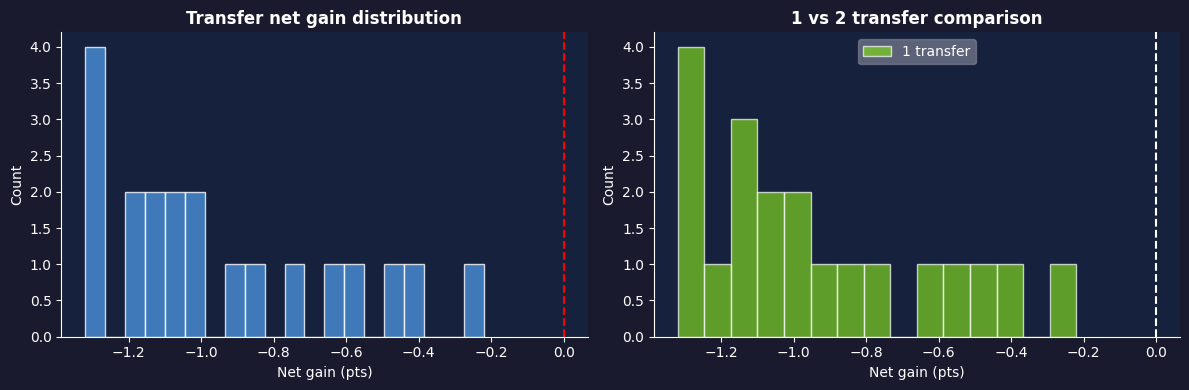

Saved to models/transfer_analysis.png


In [11]:
# Visualise the transfer gain distribution
net_gains = [t['net_gain'] for t in transfers]
n_transfers = [t['n_transfers'] for t in transfers]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Net gain distribution
axes[0].hist(net_gains, bins=20, color='#4a90d9', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Net gain (pts)', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].set_title('Transfer net gain distribution', color='white', fontweight='bold')

# 1-transfer vs 2-transfer breakdown
one_t = [t['net_gain'] for t in transfers if t['n_transfers'] == 1]
two_t = [t['net_gain'] for t in transfers if t['n_transfers'] == 2]

if one_t:
    axes[1].hist(one_t, bins=15, color='#7ed321', alpha=0.7, label='1 transfer', edgecolor='white')
if two_t:
    axes[1].hist(two_t, bins=15, color='#e74c3c', alpha=0.7, label='2 transfers', edgecolor='white')
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Net gain (pts)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_title('1 vs 2 transfer comparison', color='white', fontweight='bold')
axes[1].legend(labelcolor='white', framealpha=0.3)

plt.tight_layout()
plt.savefig(MODELS / 'transfer_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to models/transfer_analysis.png')

## 6. Budget sensitivity analysis

How much does the predicted squad value improve as we increase the budget
from £85m to £105m? This helps understand the marginal value of spending.

In [12]:
budgets = np.arange(85, 106, 1.0)  # £85m to £105m in £1m steps
predicted_totals = []
total_costs      = []

for b in budgets:
    r = optimizer.select_squad(players_available, budget=float(b))
    if r['status'] == 'Optimal':
        predicted_totals.append(r['predicted_total'])
        total_costs.append(r['total_cost'])
    else:
        predicted_totals.append(None)
        total_costs.append(None)

print('Budget sensitivity:')
print(f'{"Budget":>8} | {"Cost":>6} | {"Pred pts":>9}')
print('-' * 30)
for b, c, p in zip(budgets, total_costs, predicted_totals):
    if p is not None:
        print(f'£{b:>5.0f}m  | £{c:>4.1f}m  | {p:>9.2f}')

Budget sensitivity:
  Budget |   Cost |  Pred pts
------------------------------
£   85m  | £84.3m  |    111.00
£   86m  | £84.3m  |    111.00
£   87m  | £86.5m  |    111.57
£   88m  | £86.5m  |    111.57
£   89m  | £86.5m  |    111.57
£   90m  | £86.5m  |    111.57
£   91m  | £86.5m  |    111.57
£   92m  | £86.5m  |    111.57
£   93m  | £86.5m  |    111.57
£   94m  | £86.5m  |    111.57
£   95m  | £86.5m  |    111.57
£   96m  | £86.5m  |    111.57
£   97m  | £86.5m  |    111.57
£   98m  | £86.5m  |    111.57
£   99m  | £86.5m  |    111.57
£  100m  | £86.5m  |    111.57
£  101m  | £86.5m  |    111.57
£  102m  | £86.5m  |    111.57
£  103m  | £86.5m  |    111.57
£  104m  | £86.5m  |    111.57
£  105m  | £86.5m  |    111.57


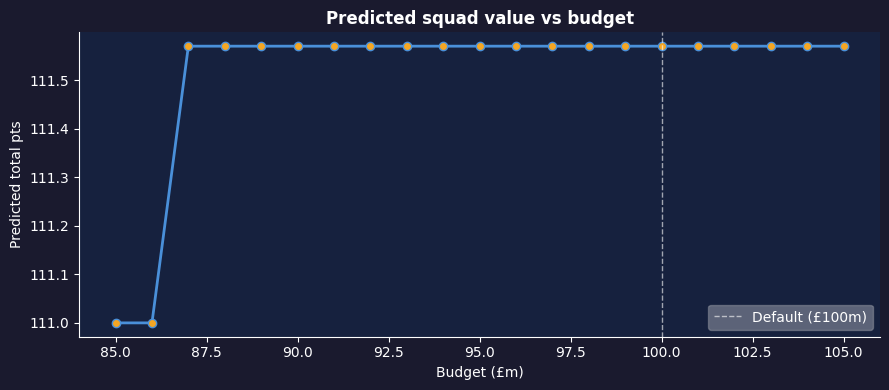

Saved to models/budget_sensitivity.png


In [13]:
valid = [(b, p) for b, p in zip(budgets, predicted_totals) if p is not None]
bx, py = zip(*valid)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

ax.plot(bx, py, marker='o', linewidth=2, color='#4a90d9',
        markersize=6, markerfacecolor='#f5a623')
ax.axvline(x=100, color='white', linestyle='--', linewidth=1, alpha=0.6, label='Default (£100m)')

ax.set_xlabel('Budget (£m)', color='white')
ax.set_ylabel('Predicted total pts', color='white')
ax.set_title('Predicted squad value vs budget', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.legend(labelcolor='white', framealpha=0.3)
for spine in ax.spines.values():
    spine.set_edgecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS / 'budget_sensitivity.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to models/budget_sensitivity.png')

## 7. Top value players (predicted pts per £m)

In [14]:
# Points per million — useful for finding differentials
players_with_preds = players_available[players_available['predicted_pts'] > 1.0].copy()
players_with_preds['pts_per_million'] = (
    players_with_preds['predicted_pts'] / players_with_preds['now_cost']
)

print('=== Top 15 value players (predicted pts per £m) ===')
top_value = players_with_preds.sort_values('pts_per_million', ascending=False).head(15)
print(top_value[['web_name', 'position', 'now_cost', 'predicted_pts', 'pts_per_million']]
      .to_string(index=False, float_format='{:.2f}'.format))

print()
print('=== Top 15 overall predicted scorers ===')
top_scorers = players_with_preds.sort_values('predicted_pts', ascending=False).head(15)
print(top_scorers[['web_name', 'position', 'now_cost', 'predicted_pts', 'pts_per_million']]
      .to_string(index=False, float_format='{:.2f}'.format))

=== Top 15 value players (predicted pts per £m) ===
   web_name position  now_cost  predicted_pts  pts_per_million
 N.Williams      DEF      4.70          10.70             2.28
 Milenković      DEF      5.10           7.73             1.52
   Kelleher      GKP      4.80           7.19             1.50
       Sels      GKP      4.60           5.96             1.30
       Aina      DEF      4.70           5.81             1.24
      Bijol      DEF      3.90           4.71             1.21
     Wilson      MID      6.00           7.23             1.21
    Murillo      DEF      5.20           6.15             1.18
    Collins      DEF      4.90           5.64             1.15
      Konsa      DEF      4.40           4.97             1.13
       King      MID      4.40           4.97             1.13
   Flemming      FWD      5.30           5.86             1.11
      Rodon      DEF      3.90           4.29             1.10
B.Fernandes      MID     10.10          10.93             1.08
   

## 8. Summary

| Metric | Value |
|--------|-------|
| Optimizer | Integer Linear Programming (PuLP / CBC) |
| Squad size | 15 players |
| Constraints | Budget £100m, position counts, max 3 per club |
| Captain selection | Highest predicted pts in squad |
| Transfer advisor | All 1- and 2-player swaps, hit penalty = −4 pts/extra transfer |
| Budget sensitivity | Squad value increases non-linearly with budget |

The `FPLOptimizer` class in `src/models/optimize.py` is now ready to be
wired into the Dash application (Phase 7).